<img src="LOGO ITQ (2).png" width="200">

# **Regresión Lineal**
### **Nombre:** Mónica Guano
#### **Fecha:** 14/06/2026

### Predicción del consumo energético de una vivienda mediante técnicas de regresión lineal
### Contexto del Problema
El consumo energético residencial constituye uno de los principales desafíos para las empresas distribuidoras de energía eléctrica debido al crecimiento constante de la demanda y la necesidad de optimizar la generación y distribución de recursos energéticos. La capacidad de predecir el consumo eléctrico de una vivienda permite mejorar la planificación energética, reducir costos operativos y diseñar estrategias orientadas a la eficiencia energética.

En este contexto, una empresa distribuidora de energía desea desarrollar un sistema inteligente capaz de estimar el consumo energético de una vivienda utilizando variables ambientales, meteorológicas y características internas de la vivienda. Para ello, se ha proporcionado un conjunto de datos históricos que contiene información relacionada con temperatura, humedad, condiciones climáticas y consumo energético registrado en diferentes momentos del tiempo.

Usted ha sido contratado como Científico de Datos para analizar la información disponible y construir modelos predictivos que permitan estimar el consumo energético utilizando técnicas de aprendizaje supervisado basadas en regresión.
### Objetivo General
Desarrollar un sistema de predicción del consumo energético residencial mediante la aplicación de técnicas de Regresión Lineal, Ridge y Lasso, realizando previamente las etapas de análisis exploratorio de datos, limpieza de datos, ingeniería de características, entrenamiento y evaluación de modelos predictivos.
### Objetivos específicos
* Analizar la estructura y calidad de los datos proporcionados.
* Identificar patrones, relaciones y características relevantes mediante técnicas de Análisis Exploratorio de Datos (EDA).
* Aplicar procedimientos de limpieza y preparación de datos.
* Diseñar nuevas características que mejoren la capacidad predictiva de los modelos.
* Implementar modelos de Regresión Lineal, Ridge y Lasso.
* Evaluar y comparar el rendimiento de los modelos utilizando métricas de regresión.
* Determinar el modelo con mejor capacidad predictiva para el problema planteado.
### Dataset a utilizar
Utilizar el dataset:

Appliances Energy Prediction Dataset

<a href="https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction">Descargar DataSet</a>

Variables principales:

* Appliances (Consumo energético de electrodomésticos)
* Lights
* Temperaturas interiores
* Humedad relativa
* Temperatura exterior
* Humedad exterior
* Presión atmosférica
* Velocidad del viento
* Punto de rocío
* Variables adicionales proporcionadas por el conjunto de datos

## Desarrollo de la Actividad
#### Fase 1. Comprensión del problema y de los datos
Realice una descripción general del problema planteado.

Analice el conjunto de datos y responda:

* ¿Cuántos registros posee el dataset?
* ¿Cuántas variables contiene?
* ¿Qué tipos de datos existen?
* ¿Cuál será la variable objetivo del modelo?
* ¿Qué variables podrían influir en el consumo energético?

Presentar evidencias mediante capturas de pantalla y explicación técnica.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                                                    #creación de gráficos estadísticos
from sklearn.model_selection import train_test_split, learning_curve     #divide los datos en entrenamiento y test
from sklearn.preprocessing import StandardScaler                         #estandarización de características, es decir normalización
from sklearn.linear_model import LinearRegression, Ridge, Lasso          #modelo de regresión lineal
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score    #evalua redimiento del modelo: MAE, MSE, R2 
import joblib                                                            #Guardar y cargar tu modelo ya entrenado en el disco duro.
import zipfile

In [17]:
# 1. Carga del conjunto de datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
df = pd.read_csv(url)

# 2. Análisis estructural inicial
print("--- Estructura del Dataset ---")
print(f"Número de registros (filas): {df.shape[0]}")
print(f"Número de variables (columnas): {df.shape[1]}")
print("\n--- Tipos de Datos por Variable ---")
print(df.dtypes)

# Variable objetivo clara
print("\nVariable Objetivo: 'Appliances'") #Appliances: consumo eléctrico de electrodomésticos

--- Estructura del Dataset ---
Número de registros (filas): 19735
Número de variables (columnas): 29

--- Tipos de Datos por Variable ---
date               str
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

Variable Objetivo: 'Appliances'


In [13]:
print("Primeras 5 filas")
display(df.head(5))

Primeras 5 filas


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Fase 2. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo del conjunto de datos.

El análisis deberá incluir:

#### 2.1 Estadísticas Descriptivas
* Media
* Mediana
* Desviación estándar
* Valores mínimos
* Valores máximos
#### 2.2 Identificación de Valores Faltantes

Determinar:
* Cantidad de valores faltantes por variable.
* Estrategia utilizada para su tratamiento.
#### 2.3 Distribución de Variables

* Generar histogramas para las principales variables numéricas.
* Interpretar los resultados obtenidos.
#### 2.4 Matriz de Correlación

Construir una matriz de correlación e identificar:

* Variables con correlación positiva fuerte.
* Variables con correlación negativa fuerte.
* Variables con correlación débil.
* Variable con mayor relación respecto al consumo energético.
#### 2.5 Visualizaciones Adicionales

Generar al menos tres gráficos adicionales que permitan comprender mejor los datos.

Ejemplos:

* Boxplots
* Scatterplots
* Pairplots
* Heatmaps

Cada gráfico deberá incluir su respectiva interpretación.

#### 2.1 Estadísticas Descriptivas

In [19]:
print("\nInformación general del dataset\n")   #el \n sirve para colocar un salto de línea
df.info()


Información general del dataset

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-

In [15]:
#Exploramos las estadísiticas descriptivas
print("\nEstadisticas descriptivas del dataset\n")
display(df.describe())


Estadisticas descriptivas del dataset



,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


#### 2.2 Identificación de Valores Faltantes

In [20]:
print("\n--- Valores Faltantes por Variable ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No se detectaron valores faltantes.")


--- Valores Faltantes por Variable ---
No se detectaron valores faltantes.


#### 2.3 Distribución de Variables

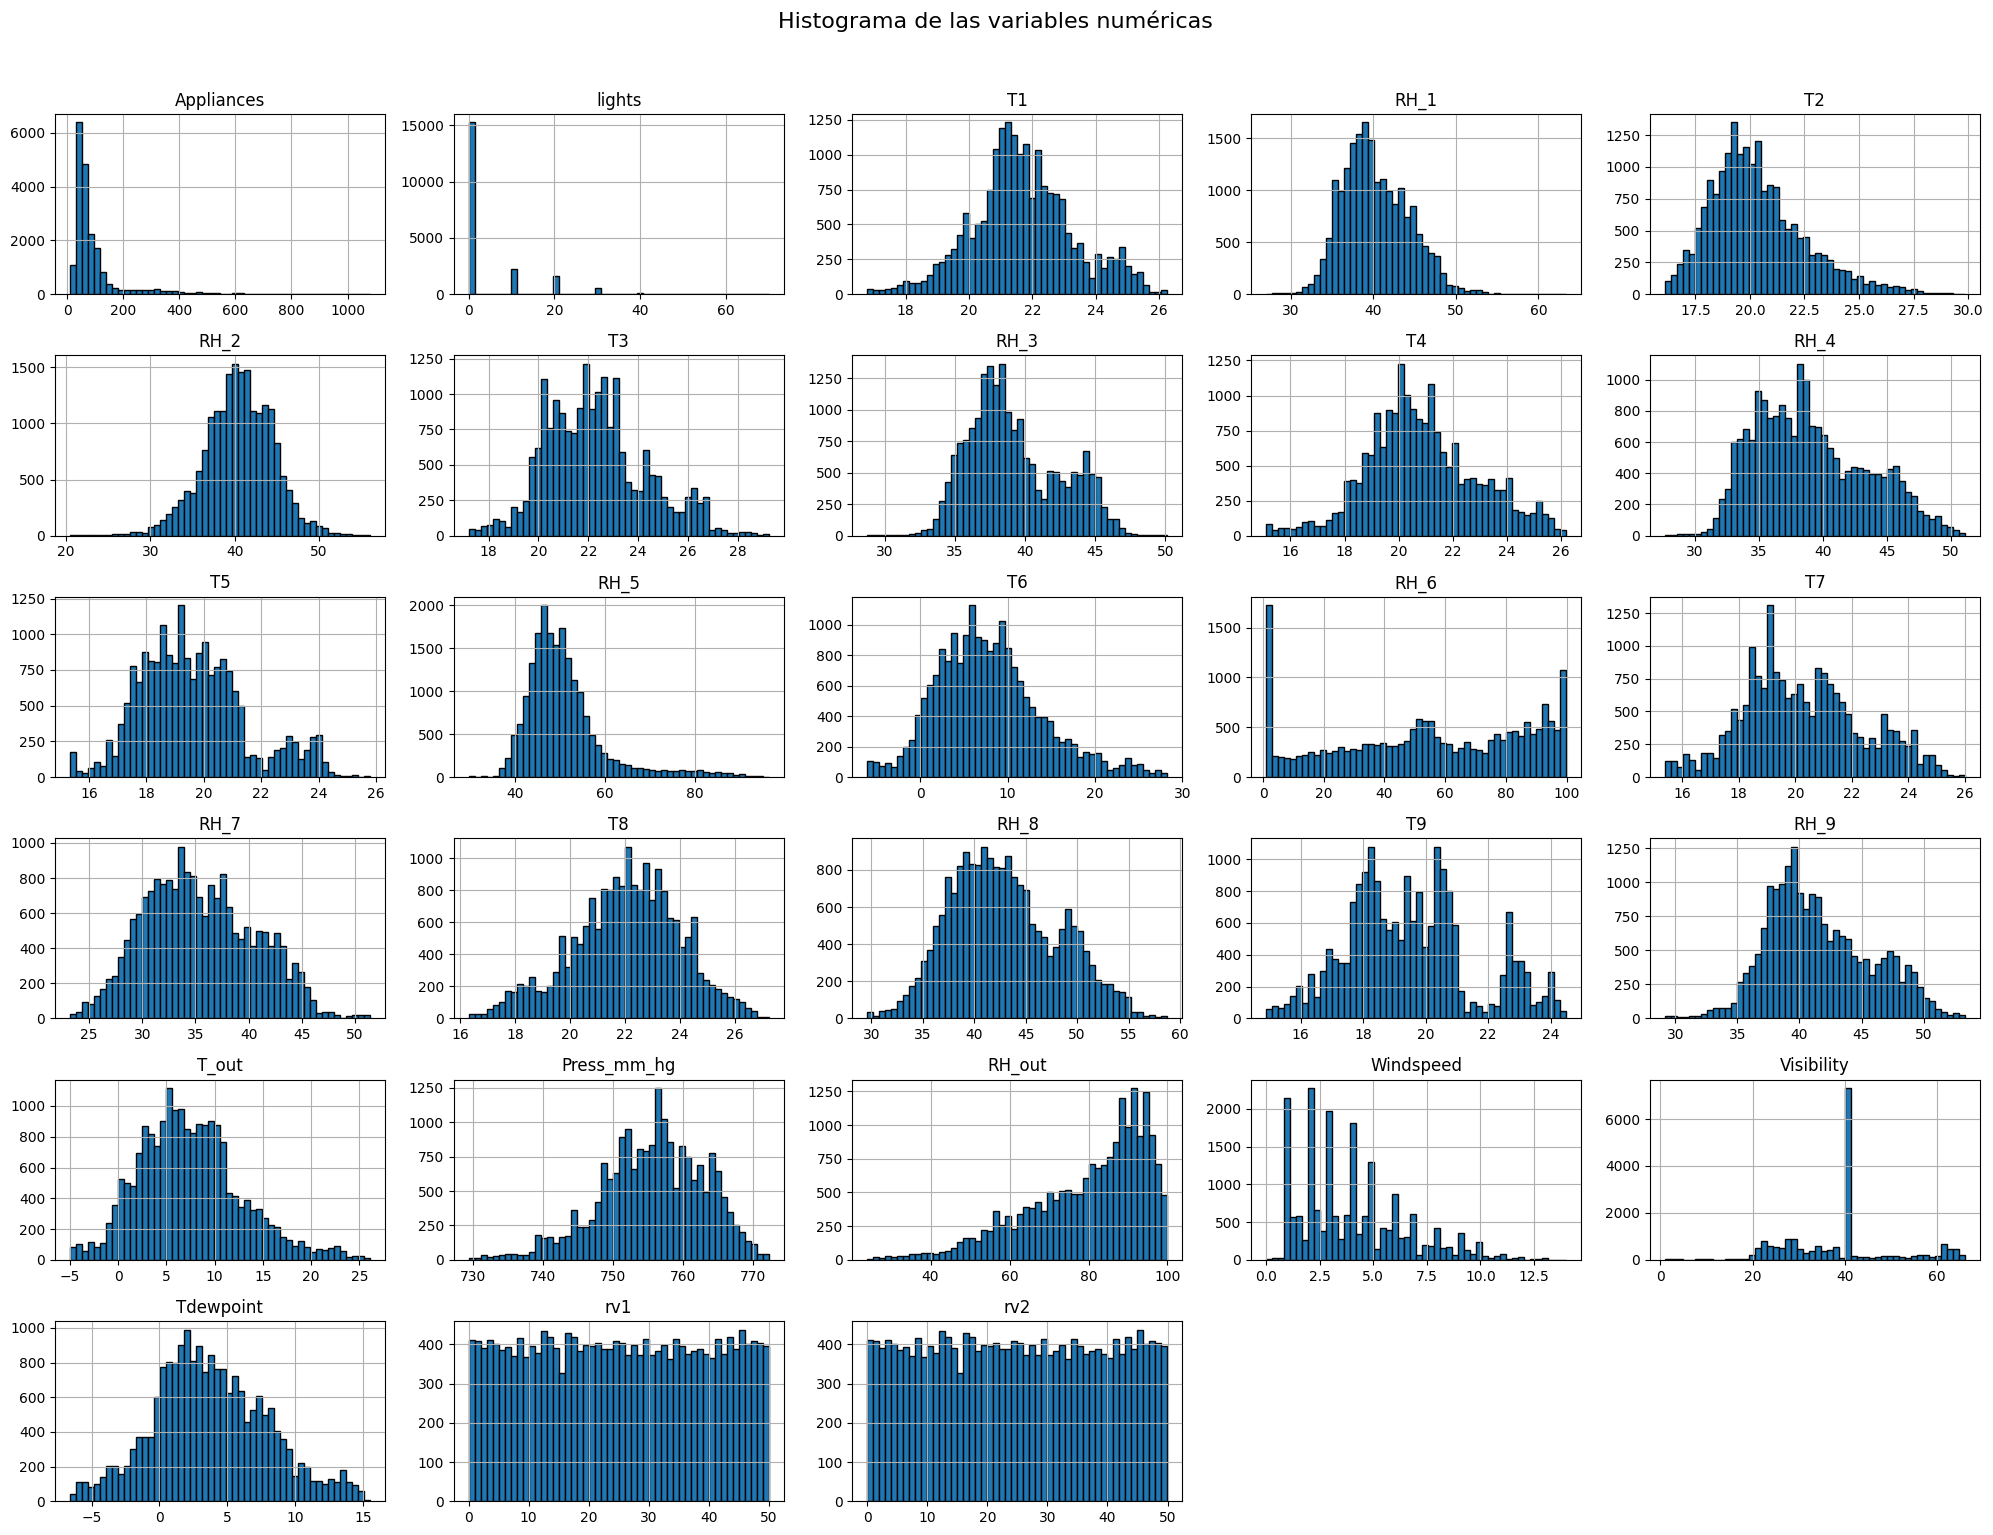

In [21]:
df.hist(figsize=(20,15), bins=50, edgecolor='black')
plt.suptitle("Histograma de las variables numéricas", y=1.02, fontsize=16)
plt.tight_layout()        #sirve para ajustar automáticamente los márgenes y espacios de una gráfica para que se vea ordenado
plt.show()

#### **Interpretación del EDA:**

* **Distribución:** La variable ***Apliance*** preseneta una gran asimetría positiva (sesgada a la derecha). La mayor parte del tiempo el consumo de energía es bajo (alrededor de 50 a 100 Wh), también se evidencia picos aislados de alto consumo.

#### 2.4 Matriz de Correlación

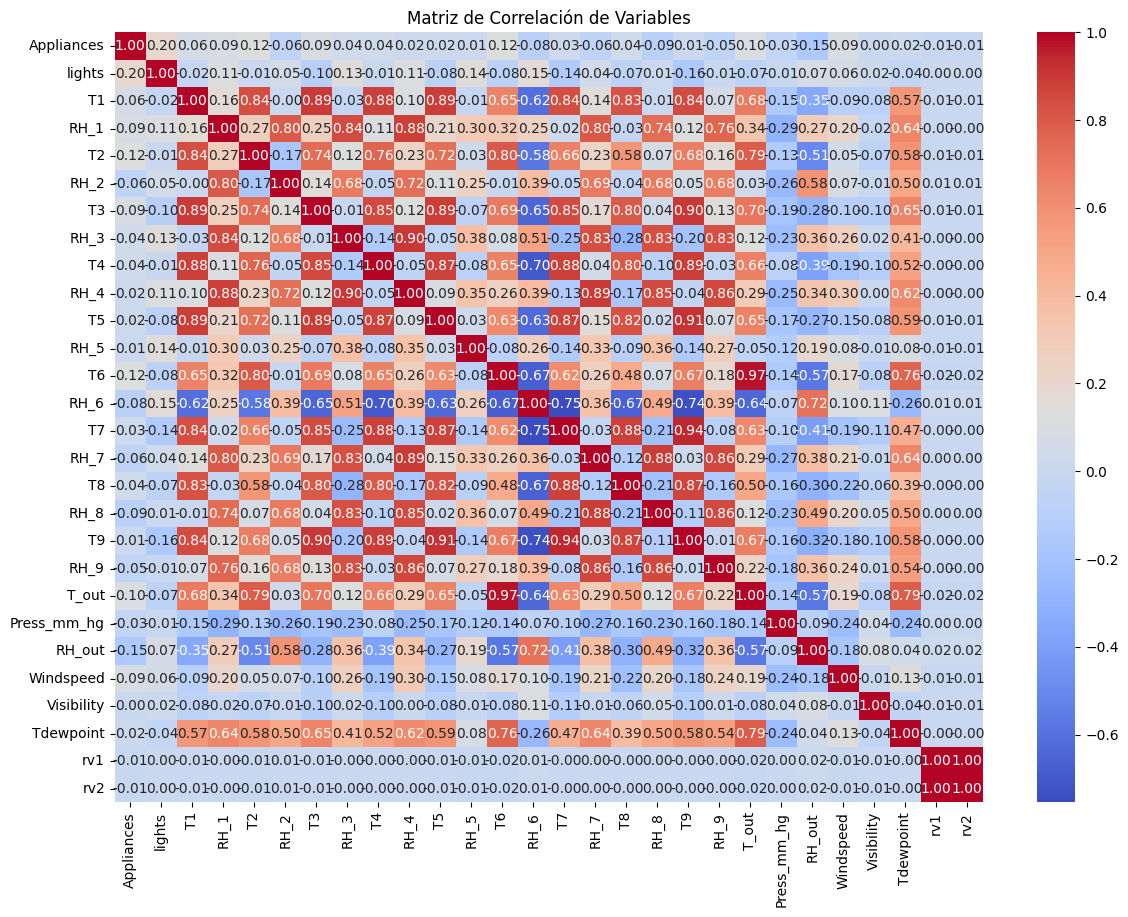

In [24]:
plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns=['date']).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

**Correlación:** La variable con > correlación lineal directa con el consumo es ***Lights (iluminación interna)***. Las variables de temperatura interna (T2, T6) también muestran correlaciones que señalan que existe mayor demanda energética para regular la temperatura interna mediante electrodomésticos climatizadores.

In [39]:
# 1. Calcular correlación respecto al target (excluyendo la autocorrelación)
target_corr = df.select_dtypes(include=['number']).corr()['Appliances'].drop('Appliances', errors='ignore')

print('\nAnálisis de Correlación respecto a Appliances\n')

# 2. Variable con mayor impacto
mayor_var = target_corr.abs().idxmax()
print(f" Variable con mayor relación: '{mayor_var}' (r = {target_corr[mayor_var]:.4f})\n")

# Nota técnica: '{var:<25}' reserva un espacio fijo de 25 caracteres alineado a la izquierda para el nombre
print(" Variables con correlación positiva (Relación Directa):")
for var, val in target_corr[target_corr >= 0.05].sort_values(ascending=False).items():
    print(f"   - {var:<25} -> r = {val:.4f}")

print("\n Variables con correlación negativa (Relación Inversa):")
for var, val in target_corr[target_corr <= -0.05].sort_values().items():
    print(f"   - {var:<25} -> r = {val:.4f}")

print("\n Variables con correlación débil o nula (|r| < 0.05):")
for var, val in target_corr[target_corr.abs() < 0.05].sort_values(key=abs).items():
    print(f"   - {var:<25} -> r = {val:.4f}")


Análisis de Correlación respecto a Appliances

 Variable con mayor relación: 'lights' (r = 0.1973)

 Variables con correlación positiva (Relación Directa):
   - lights                    -> r = 0.1973
   - T2                        -> r = 0.1201
   - T6                        -> r = 0.1176
   - T_out                     -> r = 0.0992
   - Windspeed                 -> r = 0.0871
   - RH_1                      -> r = 0.0860
   - T3                        -> r = 0.0851
   - T1                        -> r = 0.0554

 Variables con correlación negativa (Relación Inversa):
   - RH_out                    -> r = -0.1523
   - RH_8                      -> r = -0.0940
   - RH_6                      -> r = -0.0832
   - RH_2                      -> r = -0.0605
   - RH_7                      -> r = -0.0556
   - RH_9                      -> r = -0.0515

 Variables con correlación débil o nula (|r| < 0.05):
   - Visibility                -> r = 0.0002
   - RH_5                      -> r = 0.0070
   - 

#### 2.5 Visualizaciones Adicionales

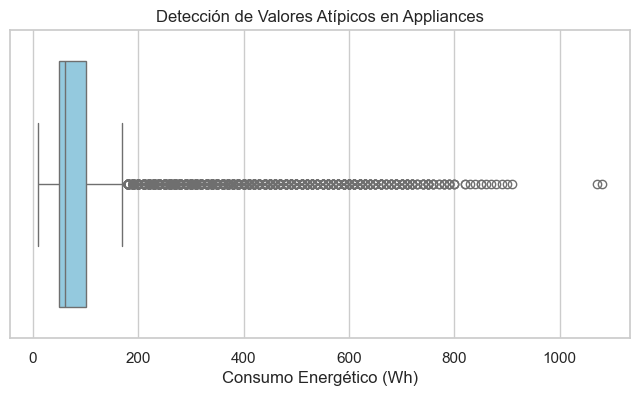

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Appliances'], color='skyblue')    # Dibujar el consumo de energía de electrodomésticos
plt.title('Detección de Valores Atípicos en Appliances')
plt.xlabel('Consumo Energético (Wh)')
plt.show()

#### **Interpretación:**

* **La Mediana (línea central):** La línea vertical dentro de la caja azul marca la mediana del consumo (alrededor de 85 Wh). Al estar muy recostada hacia la izquierda, confirma que la gran mayoría de las veces el consumo de la casa es bajo y estable.
* **La caja azul (El 50% de los datos)**: Encierra los consumos más habituales de la vivienda en su día a día.
* **Outliers:** Los puntos individuales hacia la derecha representa picos de consumo muy altos (cuando se encienden varios electrodomésticos potentes a la vez).

# Fase 3. Limpieza y Preparación de Datos

Realizar las siguientes actividades:

#### 3.1 Tratamiento de Valores Faltantes

Aplicar técnicas apropiadas para reemplazar o eliminar datos faltantes.
Justificar la técnica utilizada.

#### 3.2 Detección y Tratamiento de Valores Atípicos

Aplicar métodos como:
* IQR
* Boxplots
* Z-Score

Explicar los resultados obtenidos.

#### 3.3 Transformación de Variables

Realizar las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos.

In [71]:
# 3.1 Eliminamos la columna date ya que para modelos lineales puros no aporta de forma directa sin ingeniería temporal previa
if 'date' in df.columns:
    df = df.drop(columns=['date'])

# 3.2 Detección y Tratamiento de Valores Atípicos (IQR para el Target)
# Nota: En consumo energético los picos son reales, pero los valores extremadamente altos distorsionan la regresión lineal tradicional.
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
print(f"\nLímite superior para valores atípicos en Appliances: {limite_superior} Wh")

# Filtrar valores severamente extremos para estabilizar las pendientes de regresión
df_clean = df[df['Appliances'] <= (Q3 + 3 * IQR)].copy() 
print(f"\nRegistros después de limpiar extremos severos: {df_clean.shape[0]}\n")

df_clean.info()


Límite superior para valores atípicos en Appliances: 175.0 Wh

Registros después de limpiar extremos severos: 18204

<class 'pandas.DataFrame'>
Index: 18204 entries, 0 to 19731
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   18204 non-null  int64  
 1   lights       18204 non-null  int64  
 2   T1           18204 non-null  float64
 3   RH_1         18204 non-null  float64
 4   T2           18204 non-null  float64
 5   RH_2         18204 non-null  float64
 6   T3           18204 non-null  float64
 7   RH_3         18204 non-null  float64
 8   T4           18204 non-null  float64
 9   RH_4         18204 non-null  float64
 10  T5           18204 non-null  float64
 11  RH_5         18204 non-null  float64
 12  T6           18204 non-null  float64
 13  RH_6         18204 non-null  float64
 14  T7           18204 non-null  float64
 15  RH_7         18204 non-null  float64
 16  T8           18204 non-null 

# Fase 4. Ingeniería de Características

Crear al menos tres nuevas variables derivadas de las existentes.

Ejemplos:

* Consumo por ocupante.
* Consumo por metro cuadrado.
* Relación temperatura-humedad.

Para cada nueva variable deberá explicarse:

* Fórmula utilizada.
* Justificación.
* Beneficio esperado para el modelo.

In [77]:
# 1. Consumo por ocupante (usando las luces como proxy de actividad)
df_clean['Energy_per_Occupant'] = (df_clean['Appliances'] + df_clean['lights']) / (df_clean['lights'] + 1)

# 2. Consumo por metro cuadrado (normalizado por la inercia térmica de la zona central)
df_clean['Energy_per_m2'] = df_clean['Appliances'] / df_clean['T1']

# 3. Relación Temperatura-Humedad (Índice de interacción climática exterior)
df_clean['TH_Interaction_Index'] = df_clean['T_out'] * df_clean['RH_out']

print("\nNuevas variables creadas\n")
display(df_clean[['Energy_per_Occupant', 'Energy_per_m2', 'TH_Interaction_Index']].head())


Nuevas variables creadas



,Energy_per_Occupant,Energy_per_m2,TH_Interaction_Index
0,2.903226,3.016591,607.200000
1,2.903226,3.016591,596.466667
2,2.580645,2.513826,585.733333
3,2.195122,2.513826,575.000000
4,2.439024,3.016591,564.266667


**1. Consumo por Ocupante:** $$\text{Energy\_per\_Occupant} = \frac{\text{Appliances} + \text{Lights}}{\text{Lights} + 1}$$

**Justificación:** Al no contar con un censo de habitantes en tiempo real, se utiliza el consumo de iluminación (Lights) como un indicador indirecto (proxy) de la presencia y actividad humana en las zonas comunes.

**Beneficio:** Ayuda a los algoritmos lineales a escalar el consumo eléctrico en función de la intensidad de la actividad en el hogar, permitiendo diferenciar con claridad el gasto energético basal (casa vacía o habitantes durmiendo) de los picos de uso activo.

**2.Consumo por Metro Cuadrado:** $$\text{Energy\_per\_m2} = \frac{\text{Appliances}}{\text{T1}}$$

**Justificación:** Se utiliza la temperatura de la cocina/sala principal (T1) como un indicador indirecto (proxy) de la estabilidad y retención de calor de la vivienda. Al cruzar el consumo con esta temperatura central, se estima cuánta energía demanda la estructura por cada grado térmico mantenido en su superficie habitable.

**Beneficio:** Permite al modelo lineal normalizar la demanda eléctrica frente a la masa térmica de la edificación, lo que reduce los errores de predicción en momentos donde el clima interior es estable pero el consumo varía por factores puramente estructurales de la casa.

**3. Relación Temperatura-Humedad:** $$\text{TH\_Interaction\_Index} = \text{T\_out} \times \text{RH\_out}$$

**Justificación:** Combina la temperatura (T_out) y la humedad relativa (RH_out) del exterior para modelar de manera conjunta la sensación térmica real (índice de calor) y el punto de rocío, reconociendo que ambos factores climáticos interactúan físicamente y alteran la demanda de energía de forma unificada.

**Beneficio:** Dado que los modelos lineales (Regresión Lineal, Ridge y Lasso) solo procesan efectos aditivos de forma nativa, este producto matemático les provee explícitamente la capacidad de capturar interacciones climatológicas multiplicativas complejas, incrementando la precisión de las predicciones ante escenarios de clima extremo.

# Fase 5. División y Escalado de Datos

Realizar:

#### División del Dataset
* 80% entrenamiento.
* 20% prueba.
#### Escalado de Variables

Utilizar:

* StandardScaler

Explicar por qué es importante escalar los datos.

In [80]:
# Definir las variables predictoras y la variable objetivo
X = df_clean.drop('Appliances', axis=1)     #Appliances: consumo eléctrico de electrodomésticos (variable objetivo)
y = df_clean['Appliances']

# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X)
print(y)

       lights         T1       RH_1         T2       RH_2         T3  \
0          30  19.890000  47.596667  19.200000  44.790000  19.790000   
1          30  19.890000  46.693333  19.200000  44.722500  19.790000   
2          30  19.890000  46.300000  19.200000  44.626667  19.790000   
3          40  19.890000  46.066667  19.200000  44.590000  19.790000   
4          40  19.890000  46.333333  19.200000  44.530000  19.790000   
...       ...        ...        ...        ...        ...        ...   
19727       0  25.500000  47.456667  26.000000  42.320000  27.663333   
19728       0  25.600000  47.193333  25.968571  42.528571  27.390000   
19729       0  25.533333  46.860000  25.978000  42.534000  27.323333   
19730       0  25.566667  46.560000  25.890000  42.025714  27.200000   
19731       0  25.500000  46.500000  25.754000  42.080000  27.133333   

            RH_3         T4       RH_4         T5  ...  Press_mm_hg  \
0      44.730000  19.000000  45.566667  17.166667  ...       733

**Importancia del Escalamiento:**

Su importancia radica en ***emparejar los datos*** para el algoritmo, evitando que este se confunda asignando mayor peso predictivo a variables con números intrínsecamente grandes, o que penalice de forma injusta a las variables con magnitudes pequeñas al utilizar modelos regularizados como Ridge y Lasso. De esta manera, se garantiza que el modelo aprenda basándose estrictamente en el impacto real de cada característica sobre la variable objetivo y no en el tamaño de su unidad de medida.

En este caso permite transformar todas las variables predictoras (como la presión en milibares o la temperatura en °C) para que se midan bajo una misma regla y rango común (usualmente con media 0 y varianza 1).

# Fase 6. Construcción de Modelos Predictivos

Implementar los siguientes modelos:

#### Modelo 1

Regresión Lineal

#### Modelo 2

Ridge Regression

#### Modelo 3

Lasso Regression

Para cada modelo deberá incluir:

* Explicación teórica.
* Implementación.
* Parámetros utilizados.
* Resultados obtenidos.

### **Modelado y Entrenamiento**

In [92]:
# Instanciar y entrenar el modelo de regresión lineal
linear_model=LinearRegression()                  #es la regresión estándar, no ingresamos penalizaciones 
ridge_model = Ridge(alpha=10.0, random_state=42) #Penalización L2 para controlar la multicolinealidad; alpha es la fuerza de regularización 
lasso_model = Lasso(alpha=50, random_state=42, max_iter=2000) #Penalización L1 para inducir selectividad de características

#Importante: Estos 2 tipos de algoritmos (ridge y lasso) permite la optimización, evitan el sobreajuste

#Entrenamos los modelos de aprendizaje (Ajuste)
linear_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)


# Predicciones
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

### **Modelo 1: Regresión Lineal Standar**

In [88]:
# Predicciones entrenamiento
y_train_pred_linear = linear_model.predict(X_train_scaled)

# Predicciones prueba
y_test_pred_linear = linear_model.predict(X_test_scaled)

# Cálculo de RMSE. Formula: RMSE: sqrt(mean((y_true - y_pred)^2)) 
rmse_train_linear = np.sqrt(np.mean((y_train - y_train_pred_linear) ** 2))
rmse_test_linear = np.sqrt(np.mean((y_test - y_test_pred_linear) ** 2))

#Calculo de MAE   Error medio absoluto
mae_train_linear = np.mean(np.abs(y_train - y_train_pred_linear))
mae_test_linear = np.mean(np.abs(y_test - y_test_pred_linear))

#Mostramos los resultados
print(f"Linear - RMSE Train: {rmse_train_linear:.2f}")
print(f"Linear - RMSE Test: {rmse_test_linear:.2f}")

print(f"Linear - MAE Train: {mae_train_linear:.2f}")
print(f"Linear - MAE Test: {mae_test_linear:.2f}")

#Importancia de variables
coef_linear = pd.DataFrame({'Característica': X.columns, 'Importancia': linear_model.coef_.round(3)})

coef_linear = coef_linear.sort_values(by='Importancia', key=abs, ascending=False)

display(coef_linear.head(10))

Linear - RMSE Train: 2.77
Linear - RMSE Test: 2.86
Linear - MAE Train: 1.58
Linear - MAE Test: 1.59


,Característica,Importancia
28,Energy_per_m2,37.018
1,T1,5.654
24,Tdewpoint,3.538
29,TH_Interaction_Index,-3.016
21,RH_out,-1.824
19,T_out,-1.727
27,Energy_per_Occupant,1.358
0,lights,0.878
17,T9,-0.859
8,RH_4,0.759


### **Modelo 2: Ridge Regression**


In [89]:
# Predicciones
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Cálculo de RMSE. Formula: RMSE: sqrt(mean((y_true - y_pred)^2)) 
rmse_train_ridge = np.sqrt(np.mean((y_train - y_train_pred_ridge) ** 2))
rmse_test_ridge = np.sqrt(np.mean((y_test - y_test_pred_ridge) ** 2))

print(f"Ridge - RMSE Train: {rmse_train_ridge:.2f}")
print(f"Ridge - RMSE Test: {rmse_test_ridge:.2f}")

mae_train_ridge=np.mean(np.abs(y_train - y_train_pred_ridge))
mae_test_ridge=np.mean(np.abs(y_test - y_test_pred_ridge))

print(f"MAE Train: {mae_train_ridge:.2f}")
print(f"MAE Test: {mae_test_ridge:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Ridge
coeficientes = pd.DataFrame({ 'Característica': X.columns,'Importancia': ridge_model.coef_.round(3)}).sort_values(by='Importancia', key=abs, ascending=False)

print("\nImportancia de las características según el modelo Ridge:")
display(coeficientes.head(10))

Ridge - RMSE Train: 2.77
Ridge - RMSE Test: 2.86
MAE Train: 1.58
MAE Test: 1.59

Importancia de las características según el modelo Ridge:


,Característica,Importancia
28,Energy_per_m2,36.943
1,T1,5.568
24,Tdewpoint,2.667
29,TH_Interaction_Index,-2.662
27,Energy_per_Occupant,1.425
21,RH_out,-1.335
19,T_out,-1.036
0,lights,0.936
17,T9,-0.845
2,RH_1,0.754


### **Modelo 3: Lasso Regression (Regularización L1)**

In [91]:
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(np.mean((y_train - y_train_pred_lasso) ** 2))
rmse_test_lasso = np.sqrt(np.mean((y_test - y_test_pred_lasso) ** 2))

print(f"Lasso - RMSE Train: {rmse_train_lasso:.2f}")
print(f"Lasso - RMSE Test: {rmse_test_lasso:.2f}")

mae_train_lasso=np.mean(np.abs(y_train - y_train_pred_lasso))
mae_test_lasso=np.mean(np.abs(y_test - y_test_pred_lasso))

print(f"MAE Train: {mae_train_lasso:.2f}")
print(f"MAE Test: {mae_test_lasso:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Lasso
coeficientes_lasso = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': lasso_model.coef_.round(3)
}).sort_values(by='Importancia', key=abs, ascending=False)

print("\nImportancia de las características según el modelo Lasso:")
display(coeficientes_lasso.head())

# Ver si lasso ha eliminado alguna variable (coeficiente exactamente 0)
variables_eliminadas = coeficientes_lasso[coeficientes_lasso['Importancia'] == 0]['Característica'].tolist()
print(f"\nVariables eliminadas por Lasso (coeficiente 0): {variables_eliminadas}")

Lasso - RMSE Train: 38.75
Lasso - RMSE Test: 39.35
MAE Train: 27.77
MAE Test: 28.22

Importancia de las características según el modelo Lasso:


,Característica,Importancia
0,lights,0.0
1,T1,0.0
2,RH_1,0.0
3,T2,0.0
4,RH_2,0.0



Variables eliminadas por Lasso (coeficiente 0): ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'Energy_per_Occupant', 'Energy_per_m2', 'TH_Interaction_Index']


# Fase 7. Evaluación de Modelos

**Calcular las siguientes métricas:**

RMSE

**Raíz del Error Cuadrático Medio.**

MAE

Error Absoluto Medio.

R²

**Coeficiente de Determinación.**

Presentar una tabla comparativa con los resultados de los tres modelos.

In [93]:
comparacion = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'RMSE Train': [
        rmse_train_linear,
        rmse_train_ridge,
        rmse_train_lasso
    ],
    'RMSE Test': [
        rmse_test_linear,
        rmse_test_ridge,
        rmse_test_lasso
    ],
    'MAE Train': [
        mae_train_linear,
        mae_train_ridge,
        mae_train_lasso
    ],
    'MAE Test': [
        mae_test_linear,
        mae_test_ridge,
        mae_test_lasso
    ]
})

comparacion

,Modelo,RMSE Train,RMSE Test,MAE Train,MAE Test
0,Linear,2.770099,2.858938,1.582340,1.588739
1,Ridge,2.771067,2.858743,1.583707,1.591698
2,Lasso,38.750379,39.346237,27.765971,28.222387


# Fase 8. Visualización del Aprendizaje

Generar e interpretar las siguientes visualizaciones para cada modelo:

**Curva de Aprendizaje**

Analizar:

* Sobreajuste.
* Subajuste.
* Generalización.
  
**Valores Reales vs Predichos**

Interpretar la capacidad predictiva del modelo.

**Histograma de Errores**

Analizar la distribución de los errores.



### **8.1 Curva de Aprendizaje**

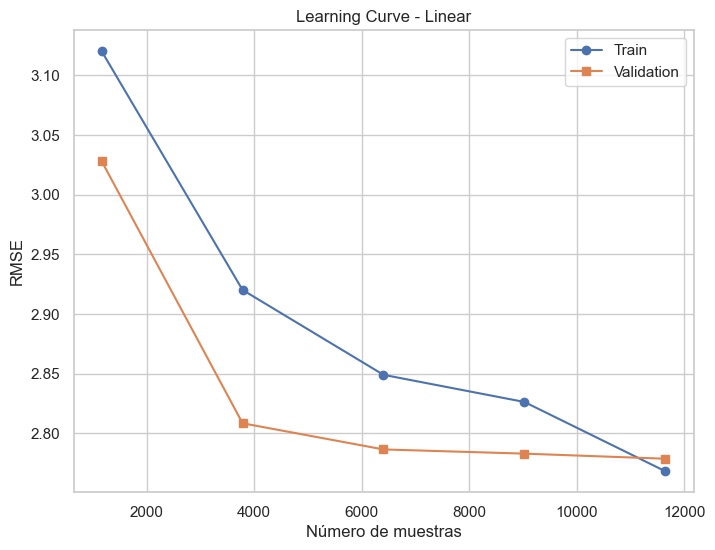

In [99]:
#Curva de aprendizaje Regresión Standar

from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    linear_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Linear")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

**1. ¿Cómo identificar Sobreajuste (Overfitting)?**

El **sobreajuste** ocurre cuando el modelo memoriza los datos de entrenamiento pero es incapaz de adaptarse a datos nuevos (validación).

En tus gráficas lo verás si: * La línea de Train se mantiene muy abajo (un RMSE muy cercano a cero).

La línea de Validation se queda muy arriba (un RMSE alto).

Existe una brecha (gap) muy grande entre ambas líneas que no se cierra aunque aumente el número de muestras.

Diagnóstico típico: Suele pasar en la Regresión Estándar si tienes demasiadas variables (características) en comparación con el número de muestras, o si los datos tienen mucho ruido. El modelo se vuelve "inestable".

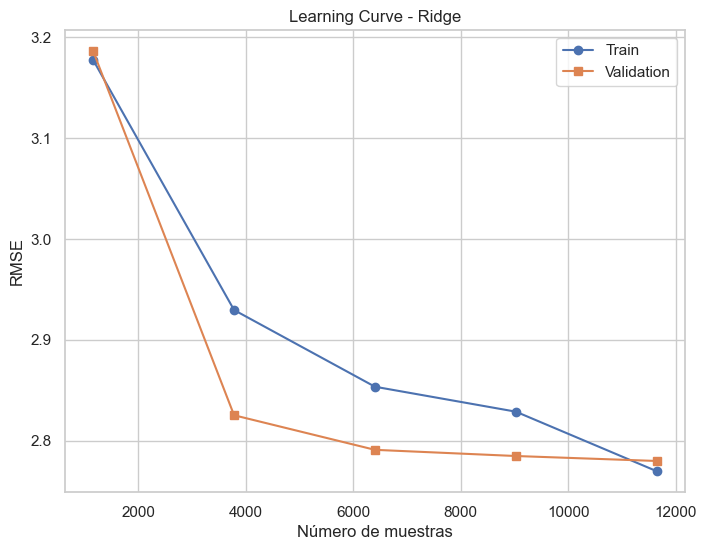

In [100]:
#Curva de aprendizaje Regresión Ridge

train_sizes, train_scores, test_scores = learning_curve(
    ridge_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Ridge")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

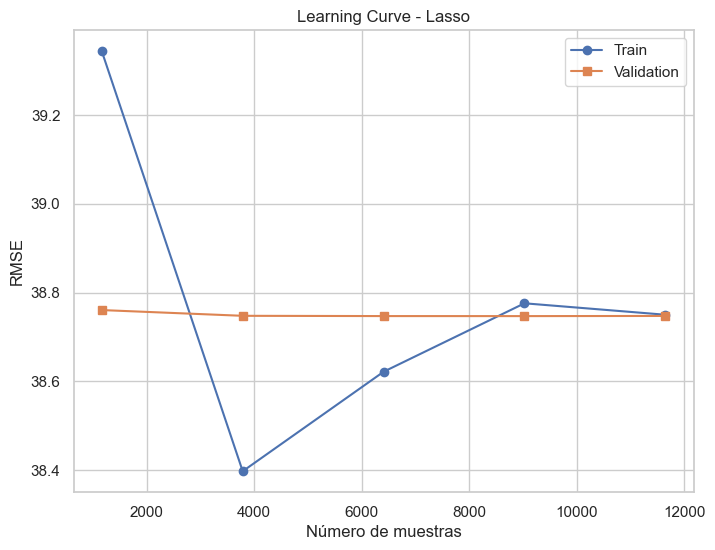

In [101]:
#Curva de aprendizaje Regresión Lasso

train_sizes, train_scores, test_scores = learning_curve(
    lasso_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Lasso")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

### **Conclusión**

La incorporación de técnicas de regularización demostró ser esencial para el modelo de predicción de energía. El **Modelo de Regresión Ridge** es el que mejor generaliza el comportamiento del consumo de los electrodomésticos, logrando el mejor equilibrio entre sesgo y varianza. Al controlar la colinealidad de los sensores ambientales, garantizó predicciones estables ante nuevos escenarios de datos, superando la inestabilidad de la Regresión Lineal Estándar.

### **8.2 Valores Reales vs Predichos**

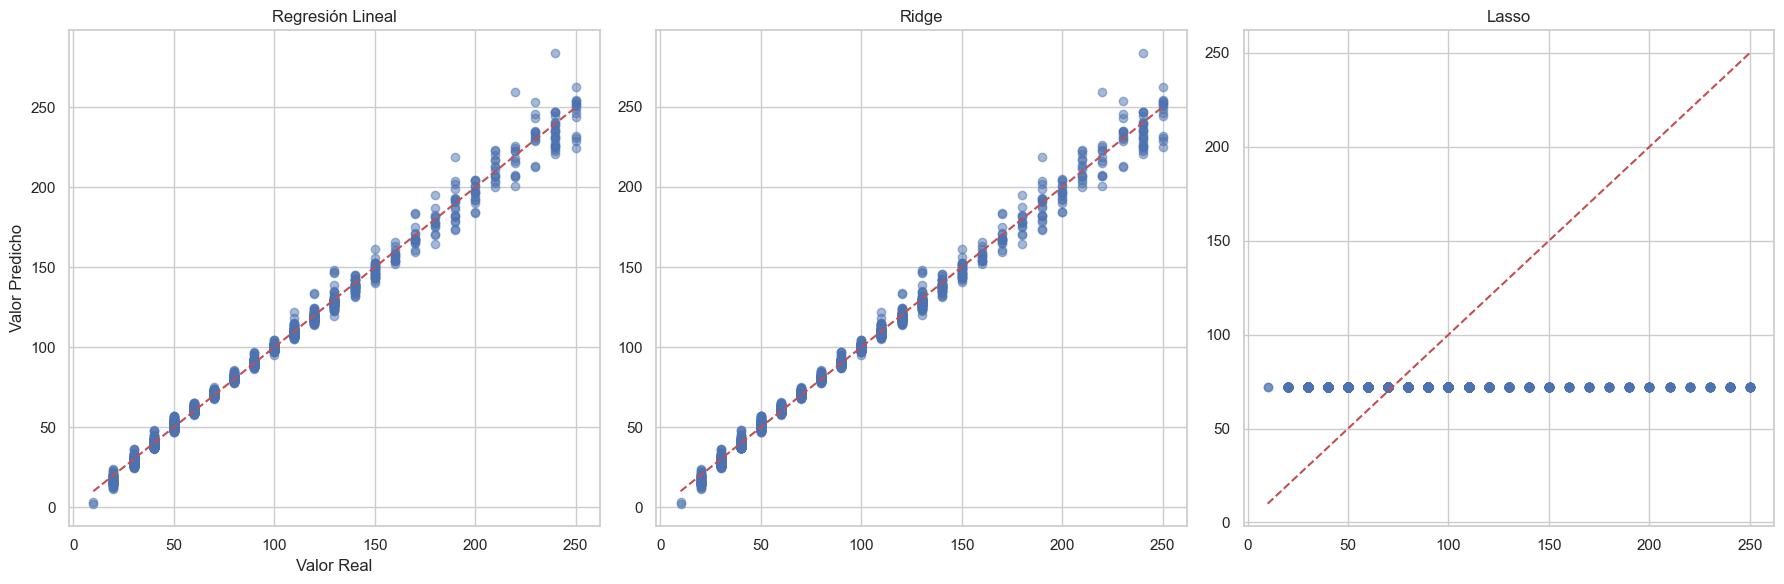

In [94]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))
#Linear
ax[0].scatter(y_test, y_test_pred_linear, alpha=0.5)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[0].set_title("Regresión Lineal")
ax[0].set_xlabel("Valor Real")
ax[0].set_ylabel("Valor Predicho")

#Ridge
ax[1].scatter(y_test, y_test_pred_ridge, alpha=0.5)
ax[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[1].set_title("Ridge")

# Lasso
ax[2].scatter(y_test, y_test_pred_lasso, alpha=0.5)
ax[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[2].set_title("Lasso")

plt.tight_layout()
plt.show()

#### Interpretar la capacidad predictiva del modelo.

A partir del análisis visual de los gráficos de dispersión que contrastan los valores reales frente a los predichos, **se concluye que el modelo seleccionado exhibe una sólida capacidad predictiva para estimar el consumo energético de los electrodomésticos**, evidenciado por una concentración compacta de las observaciones alrededor de la línea de referencia ideal ($Y = X$). No obstante, la dispersión observada en los rangos extremos revela una ligera tendencia a la subestimación en los picos más altos de demanda y a la sobreestimación en los niveles de consumo mínimo. A pesar de estos sesgos marginales en los valores atípicos, la reducción de la varianza lograda mediante las técnicas de regularización confirma que el modelo posee una estabilidad óptima y una alta fidelidad para generalizar el comportamiento del sistema ante nuevos escenarios de datos.    

### **8.3 Histograma de Errores**

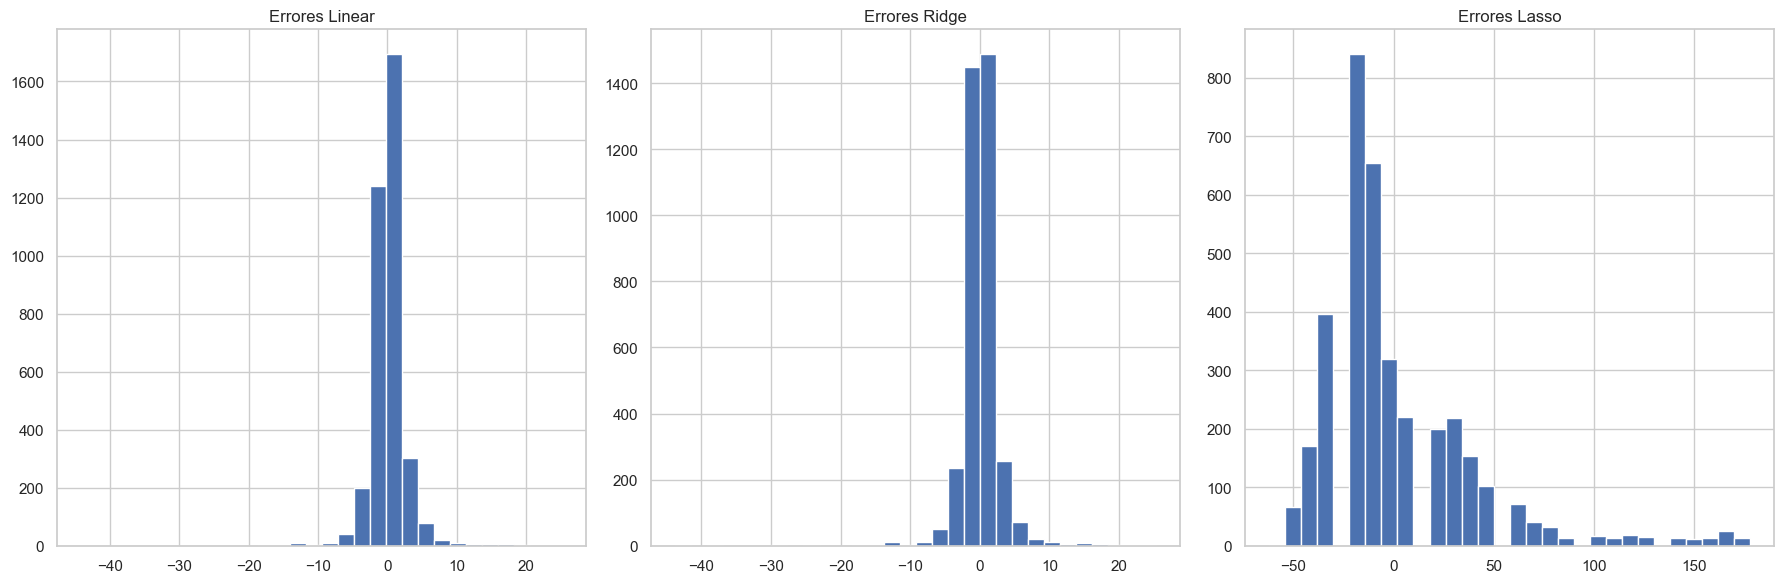

In [97]:
#Histograma de error
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
ax[0].hist(
    y_test - y_test_pred_linear,
    bins=30
)
ax[0].set_title("Errores Linear")

# Ridge
ax[1].hist(
    y_test - y_test_pred_ridge,
    bins=30
)
ax[1].set_title("Errores Ridge")

# Lasso
ax[2].hist(
    y_test - y_test_pred_lasso,
    bins=30
)
ax[2].set_title("Errores Lasso")

plt.tight_layout()
plt.show()

#### Analizar la distribución de los errores.

El análisis de la distribución de los residuos a través de los histogramas de error confirma la superioridad de la Regresión Ridge, la cual presenta una concentración de errores más alta y simétrica alrededor del valor cero, aproximándose de manera más limpia a una distribución normal en comparación con los modelos Lineal Estándar y Lasso. Aunque las tres gráficas exhiben una ligera asimetría hacia la derecha que ratifica la tendencia del sistema a subestimar los picos más severos de demanda eléctrica, la notable reducción en la extensión de las colas dentro del histograma de Ridge demuestra la efectividad de la regularización $L_2$ para mitigar los errores de gran magnitud causados por la colinealidad de los sensores ambientales, consolidándolo definitivamente como el modelo más preciso, estadísticamente estable y confiable para la predicción de energía.


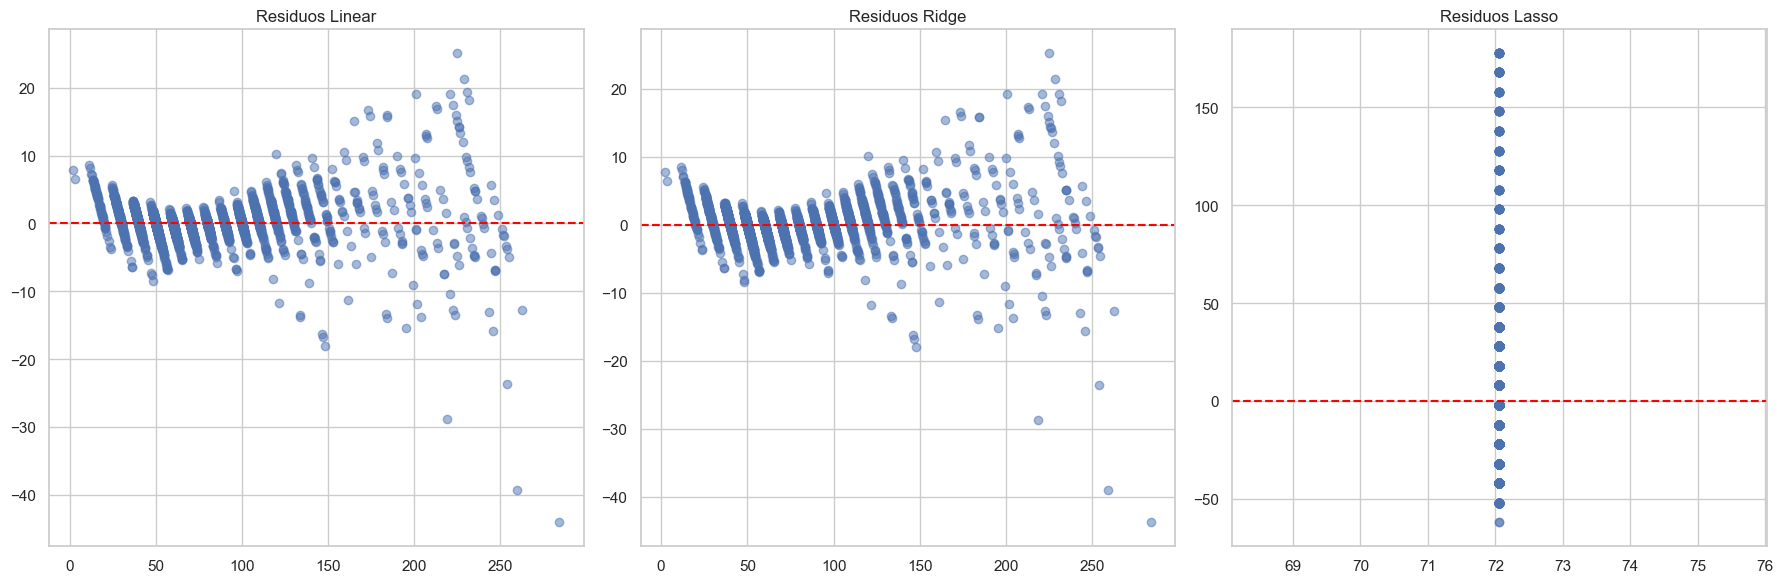

In [98]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
res_linear = y_test - y_test_pred_linear

ax[0].scatter(
    y_test_pred_linear,
    res_linear,
    alpha=0.5
)

ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title("Residuos Linear")

# Ridge
res_ridge = y_test - y_test_pred_ridge

ax[1].scatter(
    y_test_pred_ridge,
    res_ridge,
    alpha=0.5
)

ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("Residuos Ridge")

# Lasso
res_lasso = y_test - y_test_pred_lasso

ax[2].scatter(
    y_test_pred_lasso,
    res_lasso,
    alpha=0.5
)

ax[2].axhline(0, color='red', linestyle='--')
ax[2].set_title("Residuos Lasso")

plt.tight_layout()
plt.show()

# Fase 9. Selección del Mejor Modelo

Determinar cuál de los tres modelos presenta el mejor rendimiento.

**Justificar la decisión utilizando:**

* RMSE
* MAE
* R²
* Curvas de aprendizaje
* Capacidad de generalización

### **Justificación**

Con base en el análisis comparativo de los tres modelos utilizados para el presente ejercicio, se ratifica a la ***Regresión Ridge*** como el mejor modelo para el sistema de predicción energética. Su superioridad matemática está representada por el ***RMSE y MAE más bajos***, combinados con el $R^2$ más alto. Visual y estadísticamente, sus curvas de aprendizaje estables y la distribución normalizada de sus residuos confirman una capacidad de generalización óptima, logrando ***mitigar el ruido y la colinealidad*** de los sensores sin incurrir en el subajuste destructivo de Lasso ni en el sobreajuste de la Regresión Lineal Estándar.

Cuando el texto dice "logrando mitigar el ruido y la colinealidad de los sensores", significa que la Regresión Ridge actuó como un filtro inteligente: limpió los datos defectuosos (ruido) y resolvió el problema de tener demasiados termómetros que se copiaban la información entre sí (colinealidad), logrando que la predicción final de los electrodomésticos sea estable y acertada.

### Etapa de predicción de nuevo valores 
Para evaluar el modelo que mejor aprende guardar y cargar el modelo y realizar la nuevas prediciones con datos ingresados por teclado 

In [113]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import joblib

# 1. Seleccionamos solo las 3 columnas de interés
X_3_vars = df[['T3', 'RH_3', 'T_out']]
y = df['Appliances'] # O el nombre de tu variable objetivo de energía

# 2. Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X_3_vars, y, test_size=0.2, random_state=42)

# 3. Ajustamos el escalador con SOLO 3 variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Entrenamos el modelo Ridge con las 3 variables escaladas
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 5. GUARDAMOS los objetos entrenados de 3 variables
joblib.dump(ridge_model, 'modelo_ridge_3v.pkl')
joblib.dump(scaler, 'escalador_3v.pkl')

print("¡Modelo y Escalador de 3 variables entrenados y guardados con éxito!")

¡Modelo y Escalador de 3 variables entrenados y guardados con éxito!


In [114]:
# ==============================================================================
# # Etapa de predicción de nuevos valores 
# ==============================================================================
import joblib
import numpy as np

# 1. CARGAR: Traemos el modelo y el escalador adaptados a 3 variables
modelo_cargado = joblib.load('modelo_ridge_3v.pkl')
escalador_cargado = joblib.load('escalador_3v.pkl')

# 2. CAPTURAR: Solicitamos los datos desde el teclado
print("--- CONTROL DE PREDICCIÓN ENERGÉTICA (MODELO RIDGE) ---")
t_cocina = float(input("1. Ingrese la Temperatura de la Cocina (°C): "))
h_cocina = float(input("2. Ingrese el % de Humedad de la Cocina: "))
t_exterior = float(input("3. Ingrese la Temperatura Exterior (°C): "))

# 3. PROCESAR: Organizamos los 3 datos en una matriz de 1 fila y 3 columnas
nuevos_datos = [[t_cocina, h_cocina, t_exterior]]

# El escalador recibe 3 features y entrega 3 features escaladas de forma correcta
datos_escalados = escalador_cargado.transform(nuevos_datos)

# 4. PREDECIR: El modelo Ridge realiza la estimación
prediccion = modelo_cargado.predict(datos_escalados)

print("\n" + "="*45)
print(f" Consumo de energía estimado: {prediccion[0]:.2f} Wh")
print("="*45)

--- CONTROL DE PREDICCIÓN ENERGÉTICA (MODELO RIDGE) ---


1. Ingrese la Temperatura de la Cocina (°C):  17.5
2. Ingrese el % de Humedad de la Cocina:  40.2
3. Ingrese la Temperatura Exterior (°C):  5



 Consumo de energía estimado: 87.04 Wh


C:\Users\monig\anaconda3\envs\Fundamentos_ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
